# Chapter 94 — Distance Between Points

> **Prerequisites:** ch093 (Cartesian Coordinates)
>
> **Outcomes:** Derive and implement the Euclidean distance formula; Compute distances in 2D, 3D, and N dimensions; Understand distance as a metric (4 properties); Connect to norms (Part V) and similarity in ML


## The Euclidean Distance Formula

The distance between two points P = (x₁, y₁) and Q = (x₂, y₂) is:

**d(P, Q) = √((x₂-x₁)² + (y₂-y₁)²)**

Proof: draw the right triangle with hypotenuse PQ. The legs have lengths |x₂-x₁| and |y₂-y₁|.
By the Pythagorean theorem: d² = Δx² + Δy².

In 3D: d = √(Δx² + Δy² + Δz²)

In N dimensions: d = √(Σᵢ (xᵢ - yᵢ)²)

This is the **L2 norm** of the difference vector (x₂-x₁, y₂-y₁).
*(Norms formalized in ch128 — Vector Length.)*

## Metric Properties

The Euclidean distance is a **metric** — it satisfies four properties:
1. **Non-negativity:** d(P, Q) ≥ 0, with d(P, Q) = 0 iff P = Q
2. **Symmetry:** d(P, Q) = d(Q, P)
3. **Triangle inequality:** d(P, R) ≤ d(P, Q) + d(Q, R)
4. **Identity of indiscernibles:** d(P, Q) = 0 → P = Q

These properties make distance meaningful. Without the triangle inequality, "shortest path" loses its meaning.

**Other useful distances:**
- **Manhattan (L1):** |Δx| + |Δy| — sum of absolute differences; used in sparse data
- **Chebyshev (L∞):** max(|Δx|, |Δy|) — used in chessboard problems
- **Cosine distance:** 1 - cos(θ) — measures angle, not magnitude; used in text/NLP

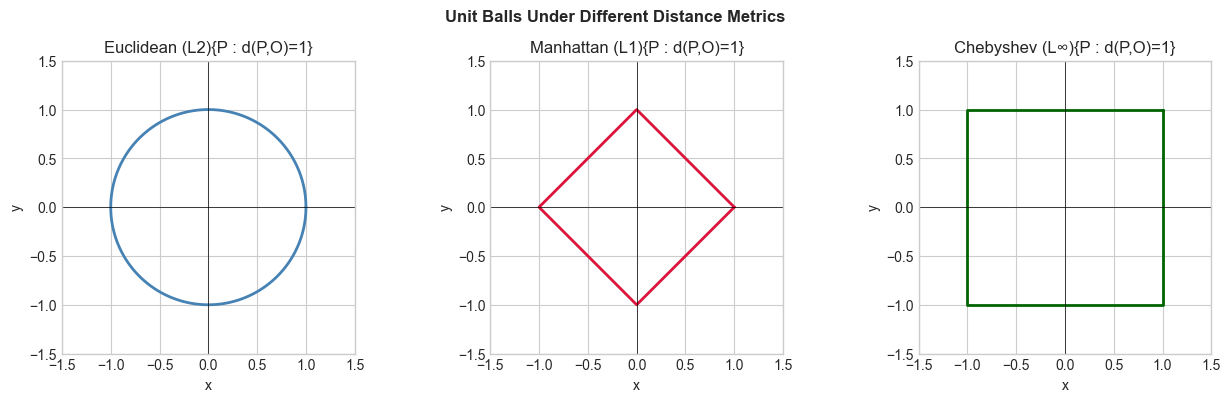

P=[1 2], Q=[4 6]
  Euclidean: 5.0000
  Manhattan: 7.0000
  Chebyshev: 4.0000
  Cosine:    0.0077


In [4]:
# --- Distance metrics comparison ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def euclidean(p, q): return np.sqrt(np.sum((p - q)**2))
def manhattan(p, q): return np.sum(np.abs(p - q))
def chebyshev(p, q): return np.max(np.abs(p - q))
def cosine_dist(p, q):
    cos = np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q) + 1e-10)
    return 1 - cos

# Visualize unit balls (all points at distance 1 from origin)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
theta = np.linspace(0, 2*np.pi, 300)

# Euclidean unit ball: circle
axes[0].plot(np.cos(theta), np.sin(theta), 'steelblue', linewidth=2)
axes[0].set_title('Euclidean (L2){P : d(P,O)=1}'); axes[0].set_aspect('equal')
axes[0].axhline(0, color='black', linewidth=0.5); axes[0].axvline(0, color='black', linewidth=0.5)

# Manhattan unit ball: diamond
diamond_x = [1,0,-1,0,1]; diamond_y = [0,1,0,-1,0]
axes[1].plot(diamond_x, diamond_y, 'crimson', linewidth=2)
axes[1].set_title('Manhattan (L1){P : d(P,O)=1}'); axes[1].set_aspect('equal')
axes[1].axhline(0, color='black', linewidth=0.5); axes[1].axvline(0, color='black', linewidth=0.5)

# Chebyshev unit ball: square
square_x = [1,1,-1,-1,1]; square_y = [1,-1,-1,1,1]
axes[2].plot(square_x, square_y, 'darkgreen', linewidth=2)
axes[2].set_title('Chebyshev (L∞){P : d(P,O)=1}'); axes[2].set_aspect('equal')
axes[2].axhline(0, color='black', linewidth=0.5); axes[2].axvline(0, color='black', linewidth=0.5)

for ax in axes:
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Unit Balls Under Different Distance Metrics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Numerical comparison
P = np.array([1, 2]); Q = np.array([4, 6])
print(f"P={P}, Q={Q}")
print(f"  Euclidean: {euclidean(P,Q):.4f}")
print(f"  Manhattan: {manhattan(P,Q):.4f}")
print(f"  Chebyshev: {chebyshev(P,Q):.4f}")
print(f"  Cosine:    {cosine_dist(P,Q):.4f}")

## N-Dimensional Distance in Practice



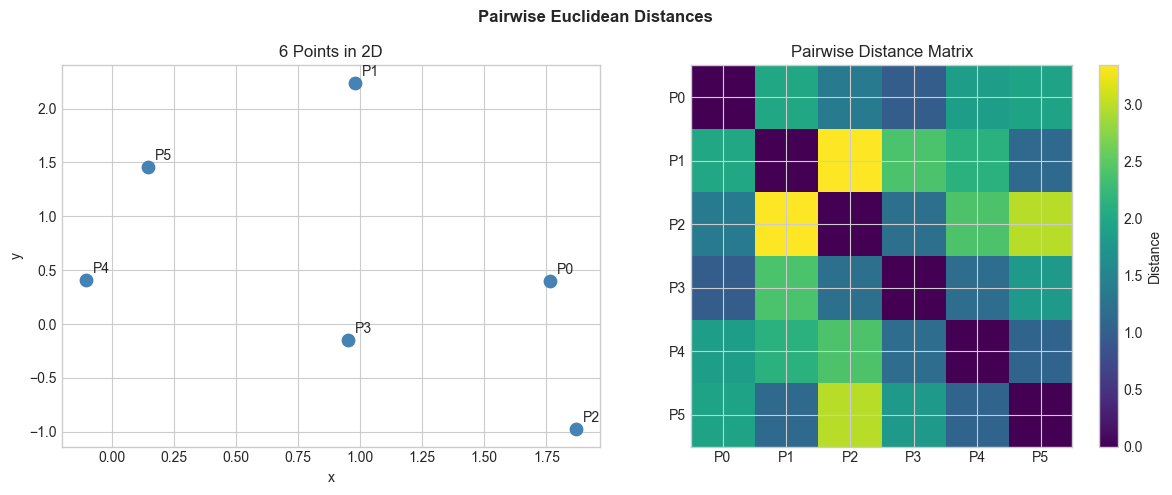

In [5]:
# --- Pairwise distance matrix ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Efficient pairwise distances for N points
def pairwise_euclidean(X):
    """
    Compute N×N distance matrix for (N, D) array X.
    Uses broadcasting: ||xi - xj||² = ||xi||² + ||xj||² - 2*xi·xj
    """
    sq_norms = np.sum(X**2, axis=1, keepdims=True)  # (N, 1)
    dot_prods = X @ X.T                              # (N, N)
    sq_dists = sq_norms + sq_norms.T - 2 * dot_prods
    sq_dists = np.maximum(0, sq_dists)               # clip numerical negatives
    return np.sqrt(sq_dists)

np.random.seed(0)
# 6 points in 2D (easy to verify)
X = np.random.randn(6, 2)
D = pairwise_euclidean(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:,0], X[:,1], s=80, color='steelblue', zorder=5)
for i, (x,y) in enumerate(X):
    axes[0].annotate(f'P{i}', (x,y), xytext=(5,5), textcoords='offset points', fontsize=10)
axes[0].set_title('6 Points in 2D'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

im = axes[1].imshow(D, cmap='viridis')
plt.colorbar(im, ax=axes[1], label='Distance')
axes[1].set_title('Pairwise Distance Matrix')
axes[1].set_xticks(range(6)); axes[1].set_yticks(range(6))
axes[1].set_xticklabels([f'P{i}' for i in range(6)])
axes[1].set_yticklabels([f'P{i}' for i in range(6)])

plt.suptitle('Pairwise Euclidean Distances', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Exercises

**Easy 1.** Compute d((0,0), (3,4)). *(Expected: 5 — this is a 3-4-5 right triangle.)*

**Easy 2.** Write a function `nearest_neighbor(query, points)` that returns the index of the closest point to query in a set.

**Medium 1.** Implement `pairwise_euclidean` without the broadcasting trick — use explicit loops. Benchmark both implementations for N=100, 500, 1000 points. Measure the speedup.

**Medium 2.** Verify the triangle inequality numerically: generate 1000 random triples (P, Q, R) and confirm d(P,R) ≤ d(P,Q) + d(Q,R) for all.

**Hard.** Implement k-nearest-neighbors classification using only pairwise distances. Given training points with labels, predict the label of a query by majority vote among its k nearest neighbors. Test on 2D data.

## Summary

- Euclidean distance: d(P,Q) = √(Σ(xᵢ-yᵢ)²) — Pythagorean theorem in N dimensions
- Distance metrics: L1 (Manhattan), L2 (Euclidean), L∞ (Chebyshev)
- Unit balls reveal the geometry of each metric
- Efficient pairwise distances use broadcasting: avoid O(N²D) loops

**Forward connections:**
- Generalized to vector norms in ch128 (Vector Length)
- Cosine similarity used in ch283 (Clustering) and ch276 (Correlation)
- Distance matrices drive k-NN, hierarchical clustering, and t-SNE